In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint as sp_randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sbn
from matplotlib.ticker import ScalarFormatter
from scipy.stats import ks_2samp
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

In [4]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

# Dataset generation

In [5]:
from classification_utility import data_pre_processing, categorical_columns_encoding, data_for_non_distance_method, data_for_distance_method, train_test_for_distance, train_test_for_non_distance, split_in_train_and_validation

- **Original dataset** after preprocessing for methods not based on distances

In [7]:
train_set, test_set, train_label, test_label=train_test_for_non_distance()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


In [8]:
print(f'TRAINING: {train_set.shape[0]} - {train_label.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 476478 - 476478
TEST: 32586 - 32586


In [25]:
TR_set, VD_set, TR_label, VD_label=split_in_train_and_validation(train_set, train_label)
print(f'TRAINING: {TR_set.shape[0]} - {TR_label.shape[0]}')
print(f'VALIDATION: {VD_set.shape[0]} - {VD_label.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

- **Standardized dataset** after preprocessing for methods based on distances

In [19]:
train_set_std, test_set_std, _, _=train_test_for_distance()

In [20]:
print(f'TRAINING: {train_set_std.shape[0]} - {train_label.shape[0]}')
print(f'TEST: {test_set_std.shape[0]} - {test_label.shape[0]}')

TRAINING: 476478 - 476478
TEST: 32586 - 32586


In [27]:
TR_set_std, VD_set_std, TR_label_std, VD_label_std=split_in_train_and_validation(train_set_std, train_label)
print(f'TRAINING: {TR_set_std.shape[0]} - {TR_label_std.shape[0]}')
print(f'VALIDATION: {VD_set_std.shape[0]} - {VD_label_std.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 333534 - 333534
VALIDATION: 142944 - 142944
TEST: 32586 - 32586


- **Random undersampled** dataset

In [11]:
rand_undersampler=RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_us, train_label_us = rand_undersampler.fit_resample(train_set, train_label)

In [12]:
print(f'TRAINING: {train_set_us.shape[0]} - {train_label_us.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 184569 - 184569
TEST: 32586 - 32586


In [28]:
TR_set_us, VD_set_us, TR_label_us, VD_label_us=split_in_train_and_validation(train_set_us, train_label_us)
print(f'TRAINING: {TR_set_us.shape[0]} - {TR_label_us.shape[0]}')
print(f'VALIDATION: {VD_set_us.shape[0]} - {VD_label_us.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 129198 - 129198
VALIDATION: 55371 - 55371
TEST: 32586 - 32586


- **Random oversampled** dataset

In [16]:
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [17]:
print(f'TRAINING: {train_set_os.shape[0]} - {train_label_os.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 672056 - 672056
TEST: 32586 - 32586


In [29]:
TR_set_os, VD_set_os, TR_label_os, VD_label_os=split_in_train_and_validation(train_set_os, train_label_os)
print(f'TRAINING: {TR_set_os.shape[0]} - {TR_label_os.shape[0]}')
print(f'VALIDATION: {VD_set_os.shape[0]} - {VD_label_os.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 470439 - 470439
VALIDATION: 201617 - 201617
TEST: 32586 - 32586


- **SMOTE oversampled** dataset

In [23]:
smote_oversampler = SMOTE(k_neighbors=5,sampling_strategy=0.67, random_state=RANDOM_STATE)
train_set_smote, train_label_smote = smote_oversampler.fit_resample(train_set_std, train_label)

In [24]:
print(f'TRAINING: {train_set_smote.shape[0]} - {train_label_smote.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 672056 - 672056
TEST: 32586 - 32586


In [30]:
TR_set_smote, VD_set_smote, TR_label_smote, VD_label_smote=split_in_train_and_validation(train_set_smote, train_label_smote)
print(f'TRAINING: {TR_set_smote.shape[0]} - {TR_label_smote.shape[0]}')
print(f'VALIDATION: {VD_set_smote.shape[0]} - {VD_label_smote.shape[0]}')
print(f'TEST: {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING: 470439 - 470439
VALIDATION: 201617 - 201617
TEST: 32586 - 32586


# Models testing

## Evaluation functions

In [31]:
def plot_PR_ROC_AUC(classifier, input_data, predicted_labels):
    # Check if the model supports predict_proba
    if not hasattr(classifier, "predict_proba"):
        print("This model does not support predict_proba().")
        return None

    # Get the probabilities of the positive classes
    y_prob = classifier.predict_proba(input_data)[:, 1]
    
    precision, recall, _ = precision_recall_curve(predicted_labels, y_prob)
    auc_pr = auc(recall, precision)  # AUC of the precision-recall curve
    print(f"AUC-PR of the classifier: {auc_pr:.4f}")

    fpr, tpr, _ = roc_curve(predicted_labels, y_prob)
    roc_auc = auc(fpr, tpr)  # AUC of the ROC curve
    print(f"AUC-ROC of the classifier: {roc_auc:.4f}")

    # Set up the figure with two subplots (side by side)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Precision-Recall Curve
    ax[0].plot(recall, precision, color='b', linewidth=2, label=f'AUC-PR = {auc_pr:.4f}')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title("Precision-Recall Curve", fontweight='bold')
    ax[0].legend(loc="best")
    ax[0].grid(alpha=0.3)

    # ROC Curve
    ax[1].plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    # Diagonal line that represents the random classifier
    ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('ROC Curve', fontweight='bold')
    ax[1].legend(loc='best')
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

In [32]:
#Custom function to print the classification report con training/valid
def print_report(train_label, train_predictions, validation_label, valid_predictions):
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print('VALIDATION SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

In [33]:
def plot_confusion_matrix(classifier, prior_labels, predicted_labels):
    cm = confusion_matrix(prior_labels, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
    disp.plot()
    plt.title("Confusion Matrix", fontweight='bold')
    plt.show()
    plt.close()

| `Metric`    | `Formula`                                                                                   | `Description`                                                        |
|---------------|-----------------------------------------------------------------------------------------------|------------------------------------------------------------------------|
| **Precision** or **TPR**| $ \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$ |Proportion of true positive predictions out of all the positive predictions (TP + FP).|
| **Recall**    | $ \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} $                                   | Proportion of true positive predictions out of all the actual positives (TP + FN).|
| **F1 Score**  | $ F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $ | Harmonic mean of Precision and Recall, balancing both metrics.|
| **FPR**  | $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$ | Proportion of the "real" negatives classified as positive.|
| **Accuracy**  | $\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{FP} + \text{TN} + \text{FN}}$ | Proportion of the correct predictions. Not the best metric to consider in inbalanced settings.|

The **AUC-ROC** is a measure of the separability of the two classes by the defined classifier. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1.

The **AUC-Precision/Recall** is a useful measure of success of prediction when the classes are very imbalanced. The PR AUC quantifies how well a model can distinguish between classes, considering both its ability to not mark a negative sample as positive (Precision) and its ability to find all the positive samples (Recall). PR AUC is often used when dealing with imbalanced datasets.


## Decision Tree

**Parameters**: <br>
- `max_depth`: Controls the maximum depth of the tree; If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. If too high the DT can better describe the training data but there is the risk of overfitting.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. 
- `max_features`: The number of features to consider when looking for the best split.
- `criterion`: The function to measure the quality of a split. 
- `split`: The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.

In [34]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(TR_set, TR_label)

In [35]:
#predict using the decision tree
#the predict function returns the actual predicted labels: we need them for the evaluation phase
train_pred_dt = dt.predict(TR_set)
valid_pred_dt = dt.predict(VD_set)

In [36]:
print_report(TR_label, train_pred_dt, VD_label, valid_pred_dt)
# 'Macro' AVG refers to the simple average between the metrics on the 2 classes without particular weights
# 'Weighted' AVG weights the measures considering the number of instances of the two classes

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.98      0.93    281700
       top20       0.73      0.30      0.43     51834

    accuracy                           0.87    333534
   macro avg       0.81      0.64      0.68    333534
weighted avg       0.86      0.87      0.85    333534

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.88      0.98      0.93    120729
       top20       0.69      0.29      0.40     22215

    accuracy                           0.87    142944
   macro avg       0.78      0.63      0.67    142944
weighted avg       0.85      0.87      0.85    142944



In this first attempt, we immediately notice that the model has very poor *recall* and *F1-score* for the 'top 20' class (1), which is the underrepresented class. This may be due to the fact that we are in a highly unbalanced setting, since in the training and validation set 84% of the records have a label 'top-20'==0. **So in this case is crucial to assign the proper weights to the classes or using other pre-processing strategies like the Undesampling/Oversampling**.

AUC-PR of the classifier: 0.5307
AUC-ROC of the classifier: 0.8083


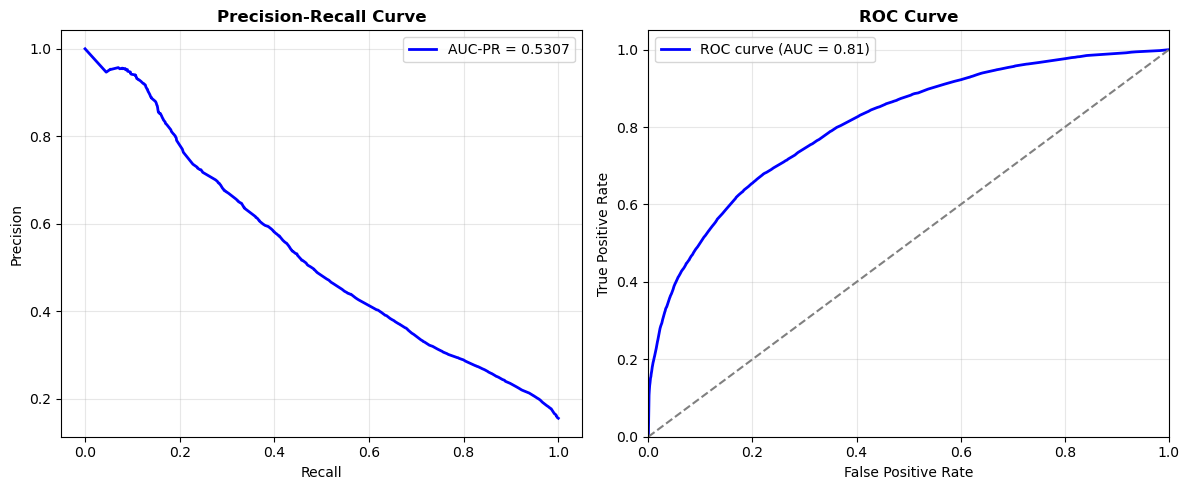

In [37]:
plot_PR_ROC_AUC(dt, VD_set, VD_label)

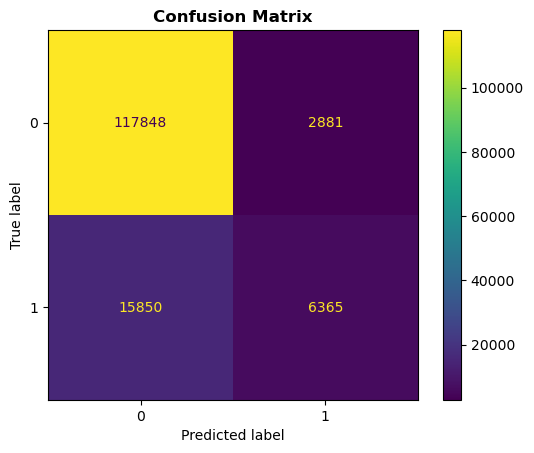

In [39]:
plot_confusion_matrix(dt, VD_label, valid_pred_dt)

As shown in the statistics, this initial configuration of the model is not able to distinguish well the data with a '1' label, since this is the minority class. In fact we have a vary low recall for this class. We need to properly manage these imbalanced classes.

### Weights adjustment

Try a Randomized GridSearch to find the best parameters of the model, including the weights given to each class. Notice that in an context where the two classes are not balanced, the *accuracy* is not the best measure to maximize in our search. It's better to use the *ROC_AUC*, which is the **area under the curve** of the *Receiver Operating Characteristics*, that takes into account the *True Positive Rate (TPR)* and the *False Positive Rate (FPR)* giving a more balanced measure of the ability to separate the two classes. Another reason to support this metric, is the fact that in this context <ins>we are interested in finding the top-20 scorers (labelled with the positive class)</ins> among all the participants.

In [65]:
def GridSearchCVExecution(hyperparameters, classifier, training_data, training_label, scoring_, cross_validation=None, max_iterations=None):
    #Parameters:
    # - hyperparameters: dictionary of the parameters of the classifier to be tested
    # - classifier: classifier to optimize.
    # - training_data / training_labels: data used to train the model with the associated labels
    # - cross_validation (int, optional): number of fold to be used in case of a cross validation
    # - scoring: metric to be optimized during the search
    # - max_iterations (int, optional): maximum number of tests for a RandomizedSearchCV.

    if max_iterations is not None:
        search = RandomizedSearchCV(
            estimator=classifier,
            param_distributions=hyperparameters,
            n_iter=max_iterations,
            n_jobs=-1,
            scoring=scoring_,
            cv=cross_validation,
            random_state=RANDOM_STATE
        )
    else:
        search = GridSearchCV(
            estimator=classifier,
            param_grid=hyperparameters,
            n_jobs=-1,
            scoring=scoring_,
            cv=cross_validation
        )

    search.fit(training_data, training_label)
    # Returns the results of the searching process
    return search


In [66]:
def save_grid_search_results(grid_result, filename="grid_search_results.txt"):
    # The function saves the grid search results in a textual file
    # The tests are sorted according to the score maximixed in the grid search (area under the curve)
    
    # Result extraction
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    
    # Generate the tuples and sort by score (desc)
    results = sorted(zip(means, stds, params), key=lambda x: x[0], reverse=True)

    with open(filename, "w") as f:
        f.write("Best configuration: %f using %s\n" % (grid_result.best_score_, grid_result.best_params_))
        f.write("Mean and std of this setting: %f - %f\n\n" % (
            grid_result.cv_results_['mean_test_score'][0], 
            grid_result.cv_results_['std_test_score'][0]
        ))
        f.write("All configurations sorted by score:\n")
        for mean, stdev, param in zip(
            grid_result.cv_results_['mean_test_score'], 
            grid_result.cv_results_['std_test_score'], 
            grid_result.cv_results_['params']
        ):
            f.write("Mean: %f, Std: %f with: %r\n" % (mean, stdev, param))

In [67]:
def retrieve_grid_search_results(filename):
    with open(filename, "r") as file:
        for i in range(3):  # The first 3 rows contain the best result and the mean/std dev of the setting
            line = file.readline().strip()
            print(line)

#### ROC AUC Grid Search

In [68]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_combined, training_label=train_label_combined, classifier=classifier, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

In [69]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_ROC_AUC_13_12.txt")

In [89]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_ROC_AUC_13_12.txt")

Best configuration: 0.813585 using {'class_weight': {0: 1, 1: 20}, 'criterion': 'gini', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 47, 'min_samples_split': 45}
Mean and std of this setting: 0.791066 - 0.002992



In [71]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:20} ,criterion='gini', splitter='best', max_depth=50, min_samples_split=45, min_samples_leaf=47, max_features='log2')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [72]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.99      0.44      0.60    325195
       top20       0.25      0.97      0.40     62926

    accuracy                           0.52    388121
   macro avg       0.62      0.70      0.50    388121
weighted avg       0.87      0.52      0.57    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.96      0.43      0.59    139370
       top20       0.24      0.92      0.38     26968

    accuracy                           0.51    166338
   macro avg       0.60      0.67      0.48    166338
weighted avg       0.85      0.51      0.56    166338



AUC-PR of the classifier: 0.5272
AUC-ROC of the classifier: 0.8107


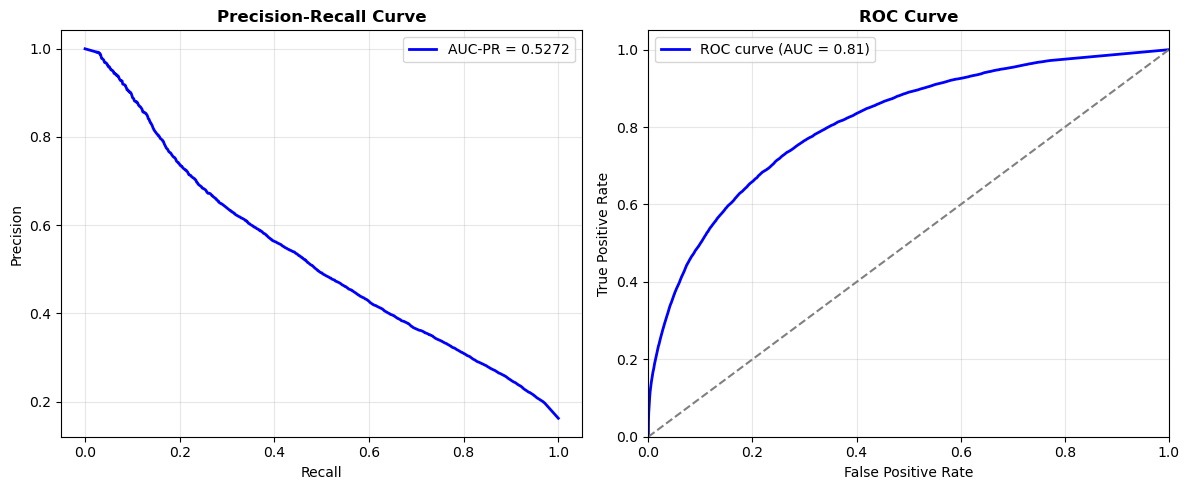

In [73]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

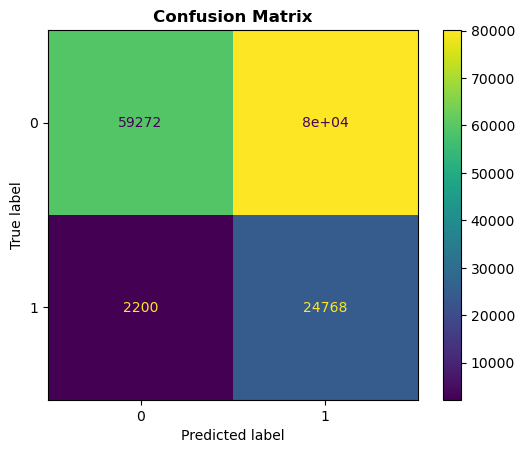

In [74]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

As we can see from the statistics, by assigning a weight ratio of 1:20, we have obtained more or less the same ROC AUC value as before, but we have worsened the recall for class 0 and the precision for class 1. Therefore, we have defined a classifier that is more biased towards class 1, as can be seen in the confusion matrix, where there are many 0 objects classified as 1.

#### Precision/Recall AUC Grid Search

In [75]:
#grid_search = GridSearchCVExecution(param_dist, training_data=train_combined, training_label=train_label_combined, classifier=classifier, scoring_='average_precision', cross_validation=cv, max_iterations=n_iter_search)
grid_search = None

In [76]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_PR_AUC_13_12.txt")

In [77]:
retrieve_grid_search_results("GridSearchResults/randomizedGridSearch_DT_PR_AUC_13_12.txt")

Best configuration: 0.539927 using {'class_weight': {0: 1, 1: 20}, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 44, 'min_samples_split': 26}
Mean and std of this setting: 0.516006 - 0.005461



In [78]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:20} ,criterion='gini', splitter='best', max_depth=30, min_samples_split=26, min_samples_leaf=44, max_features='sqrt')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [79]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.99      0.44      0.61    325195
       top20       0.25      0.97      0.40     62926

    accuracy                           0.53    388121
   macro avg       0.62      0.71      0.51    388121
weighted avg       0.87      0.53      0.58    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.96      0.43      0.59    139370
       top20       0.24      0.91      0.38     26968

    accuracy                           0.51    166338
   macro avg       0.60      0.67      0.48    166338
weighted avg       0.84      0.51      0.56    166338



AUC-PR of the classifier: 0.5241
AUC-ROC of the classifier: 0.8086


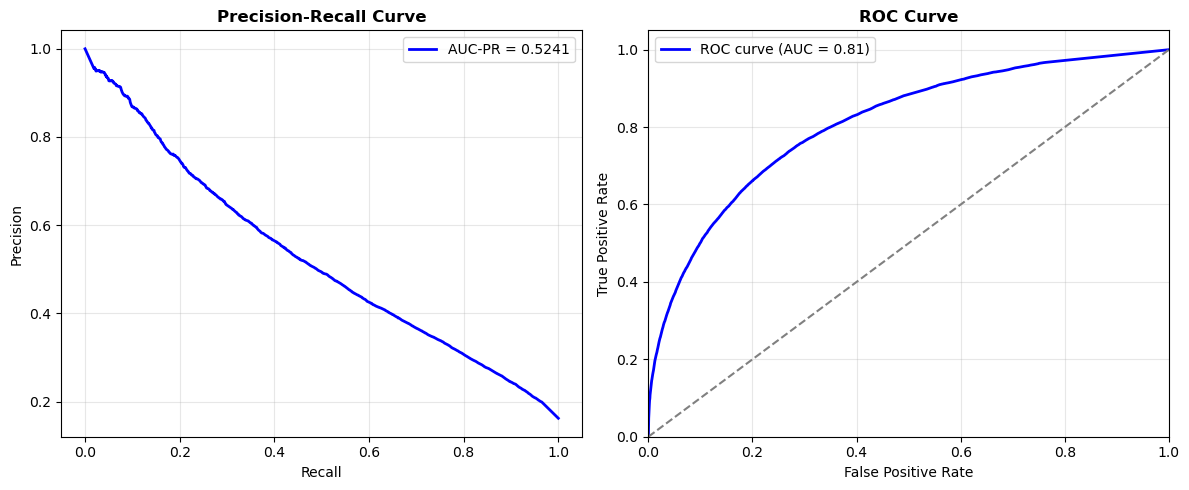

In [80]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

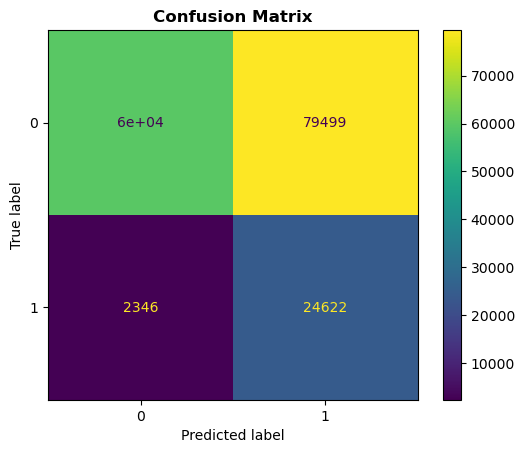

In [81]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

Basically, since we have generated a DT quite similar to the previous one, the considerarions are actually the same.

#### F1 Weighted Grid Search

In [82]:
grid_search = GridSearchCVExecution(param_dist, training_data=train_combined, training_label=train_label_combined, classifier=classifier, scoring_='f1_weighted', cross_validation=cv, max_iterations=n_iter_search)
#grid_search = None

In [83]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_F1W_14_12.txt")

In [84]:
retrieve_grid_search_results("GridSearchResults/randomizedGridSearch_DT_F1W_14_12.txt")

Best configuration: 0.784966 using {'class_weight': {0: 1, 1: 10}, 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2}
Mean and std of this setting: 0.682309 - 0.001334



In [85]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(class_weight={0:1, 1:10} ,criterion='entropy', splitter='best', max_depth=50, min_samples_split=2, min_samples_leaf=3, max_features='log2')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [86]:
print_report(train_label, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       1.00      0.84      0.92    325195
       top20       0.55      1.00      0.71     62926

    accuracy                           0.87    388121
   macro avg       0.78      0.92      0.81    388121
weighted avg       0.93      0.87      0.88    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.78      0.85    139370
       top20       0.37      0.66      0.47     26968

    accuracy                           0.76    166338
   macro avg       0.64      0.72      0.66    166338
weighted avg       0.83      0.76      0.78    166338



AUC-PR of the classifier: 0.5057
AUC-ROC of the classifier: 0.7466


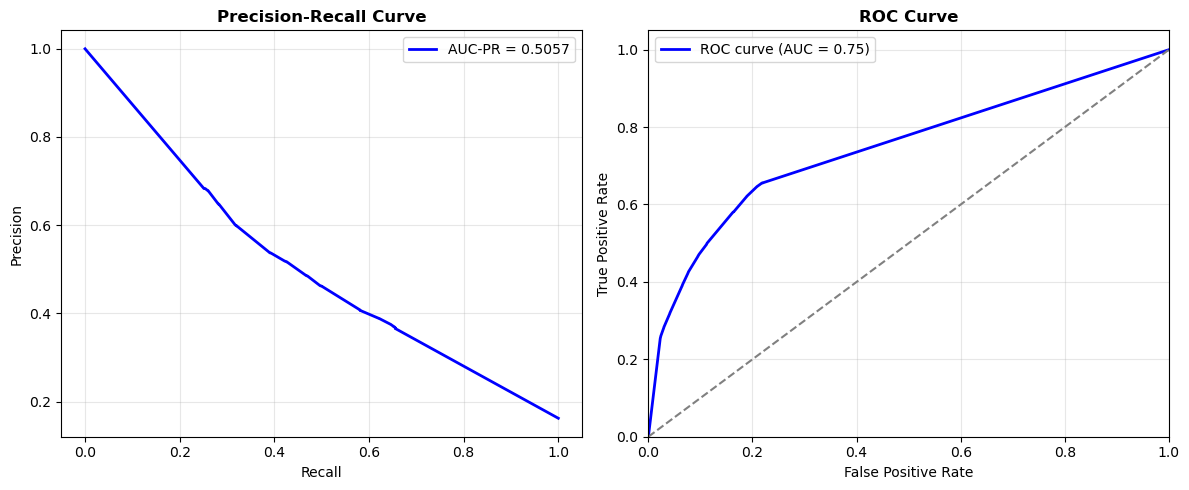

In [87]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

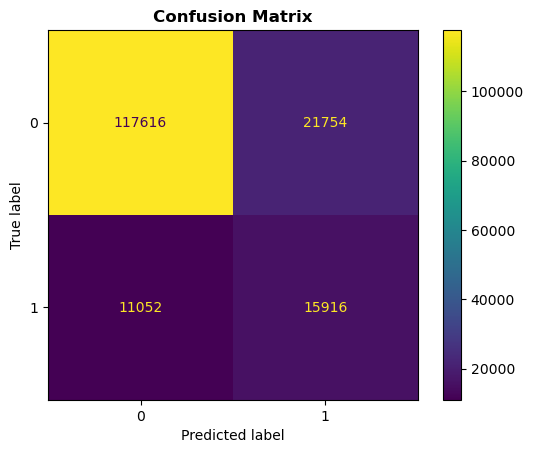

In [130]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

The statistics showed that probably we have definined a model which is overfitting our data with a 1 precision for the 0 class.

### Undersampling strategy

In [168]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(train_set_us, train_label_us)
train_pred_dt = dt.predict(train_set_us)
valid_pred_dt = dt.predict(validation_set)

In [169]:
print_report(train_label_us, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.76      0.87      0.81     93919
       top20       0.76      0.59      0.67     62926

    accuracy                           0.76    156845
   macro avg       0.76      0.73      0.74    156845
weighted avg       0.76      0.76      0.75    156845

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.85      0.88    139370
       top20       0.44      0.58      0.50     26968

    accuracy                           0.81    166338
   macro avg       0.67      0.72      0.69    166338
weighted avg       0.84      0.81      0.82    166338



In all columns, the p-value is extremely low (practically 0.0000), suggesting that all column distributions are significantly different between train_set and train_set_os (the oversampled dataset).

#### F1 Macro Grid Search
Since we have already performed a class balancing using the undersampling, let's try a grid search using the 'f1 macro' as the measure to maximise. For the same reason we do not try to change the class weights.

In [115]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_us, training_label=train_label_us, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [116]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_US_F1M_14_12.txt")

In [ ]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_US_F1M_14_12.txt")

Best configuration: 0.719442 using {'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 43}
Mean and std of this setting: 0.718758 - 0.002250



In [120]:
# define a decision tree using the parameters that have maximised the F1 Macro (in an oversampling setting)
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=15, min_samples_split=43, min_samples_leaf=6, max_features='log2')
dt = dt.fit(train_set_us, train_label_us)
train_pred_dt = dt.predict(train_set_us)
valid_pred_dt = dt.predict(validation_set)
print_report(train_label_us, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.78      0.87      0.82     93919
       top20       0.77      0.63      0.69     62926

    accuracy                           0.77    156845
   macro avg       0.77      0.75      0.76    156845
weighted avg       0.77      0.77      0.77    156845

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.84      0.88    139370
       top20       0.42      0.59      0.49     26968

    accuracy                           0.80    166338
   macro avg       0.67      0.72      0.69    166338
weighted avg       0.83      0.80      0.82    166338



AUC-PR of the classifier: 0.5057
AUC-ROC of the classifier: 0.8027


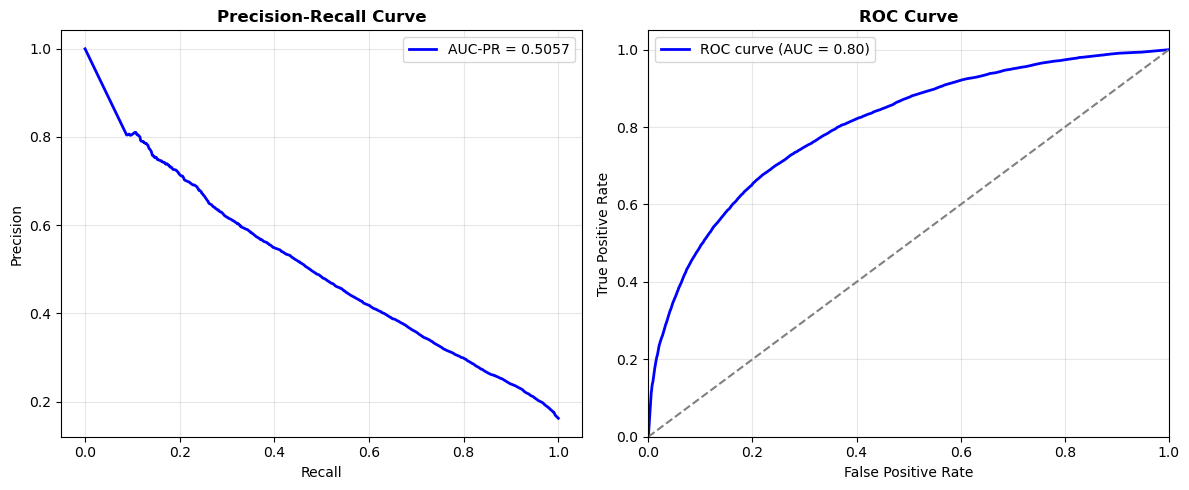

In [121]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

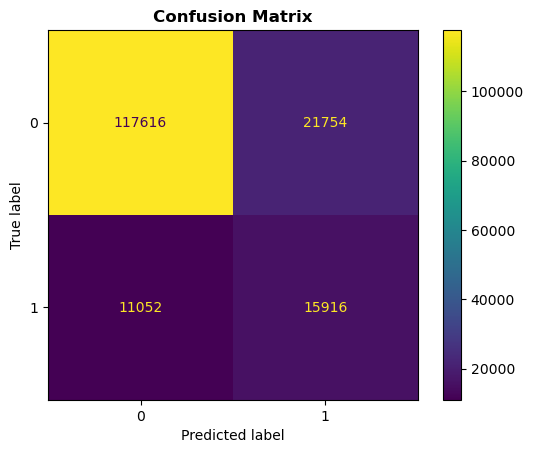

In [131]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

Even by adopting this strategy the under-represented class continues to have some limitations.

### Oversampling strategy
Over-sample the minority class by picking samples at random with replacement.

#### Random Oversampler

In [157]:
# define a decision tree and fit it. First attempt with "random" parameters
dt = tree.DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=10, min_samples_split=3, min_samples_leaf=4)
dt = dt.fit(train_set_os, train_label_os)
train_pred_dt = dt.predict(train_set_os)
valid_pred_dt = dt.predict(validation_set)

In [158]:
print_report(train_label_os, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.77      0.86      0.81    325195
       top20       0.74      0.61      0.67    217880

    accuracy                           0.76    543075
   macro avg       0.75      0.73      0.74    543075
weighted avg       0.76      0.76      0.75    543075

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.85      0.88    139370
       top20       0.44      0.59      0.50     26968

    accuracy                           0.81    166338
   macro avg       0.68      0.72      0.69    166338
weighted avg       0.84      0.81      0.82    166338



In all columns, the p-value is extremely low (practically 0.0000), suggesting that all column distributions are significantly different between train_set and train_set_os (the oversampled dataset).

In [ ]:
#to find the best set of parameter setting, we can run a grid search
# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the model
classifier = tree.DecisionTreeClassifier()

#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set_os, training_label=train_label_os, classifier=classifier, scoring_='f1_macro', cross_validation=cv, max_iterations=n_iter_search)

In [144]:
#save_grid_search_results(grid_search, filename="GridSearchResults/randomizedGridSearch_DT_OS_F1M_15_12.txt")

In [145]:
retrieve_grid_search_results(filename="GridSearchResults/randomizedGridSearch_DT_OS_F1M_15_12.txt")

Best configuration: 0.812494 using {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26}
Mean and std of this setting: 0.747280 - 0.002754



In [151]:
# define a decision tree using the parameters that have maximised the ROC AUC
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50, min_samples_split=26, min_samples_leaf=1, max_features='sqrt')
dt = dt.fit(train_set_os, train_label_os)
train_pred_dt = dt.predict(train_set_os)
valid_pred_dt = dt.predict(validation_set)
print_report(train_label_os, train_pred_dt, validation_label, valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.90      0.90    325195
       top20       0.85      0.87      0.86    217880

    accuracy                           0.89    543075
   macro avg       0.88      0.88      0.88    543075
weighted avg       0.89      0.89      0.89    543075

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.84      0.87    139370
       top20       0.41      0.56      0.47     26968

    accuracy                           0.80    166338
   macro avg       0.66      0.70      0.67    166338
weighted avg       0.83      0.80      0.81    166338



AUC-PR of the classifier: 0.4890
AUC-ROC of the classifier: 0.7573


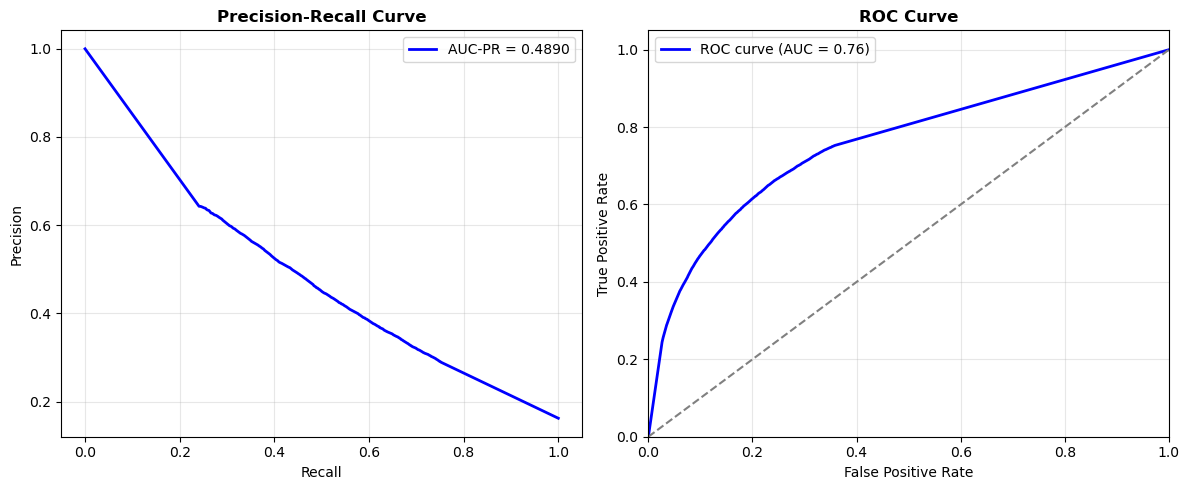

In [152]:
plot_PR_ROC_AUC(dt, validation_set, validation_label)

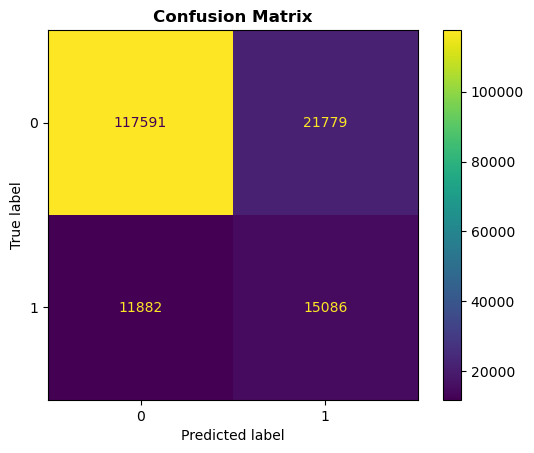

In [153]:
plot_confusion_matrix(dt, validation_label, valid_pred_dt)

#### Smote

# Spazzatura | Altri classificatori

We can observe that the mean of the configaration tested is quite similar to the best found and also the standard deviation is quite low.

In [75]:
dt = tree.DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=20, max_features='log2', min_samples_split=42, min_samples_leaf=39, class_weight='balanced')
dt = dt.fit(train_set, train_label)
train_pred_dt = dt.predict(train_set)
valid_pred_dt = dt.predict(validation_set)

In [76]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_dt)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.95      0.76      0.84    325195
       top20       0.39      0.79      0.52     62926

    accuracy                           0.76    388121
   macro avg       0.67      0.77      0.68    388121
weighted avg       0.86      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.93      0.74      0.83    139370
       top20       0.36      0.73      0.48     26968

    accuracy                           0.74    166338
   macro avg       0.65      0.74      0.65    166338
weighted avg       0.84      0.74      0.77    166338



**Considerazioni AUC-ROC**
L'area under the curve (AUC), in particolare l'AUC-ROC, è un parametro utile per valutare modelli anche in caso di dati sbilanciati, ma va utilizzato con cautela. <br>
Pro dell'AUC-ROC in caso di dati sbilanciati <br>
- Indipendenza dal Threshold: L'AUC-ROC considera la performance del modello su tutti i possibili threshold, quindi non è influenzato dalla scelta di un particolare cut-off.
- Capacità di distinguere le classi: Una AUC vicina a 1 indica che il modello è molto bravo a distinguere tra la classe positiva e quella negativa. 
- Limitazioni dell'AUC-ROC con dati sbilanciati

Ignora la Distribuzione delle Classi: L'AUC-ROC valuta solo quanto bene il modello separa le classi, ma non tiene conto del fatto che una classe sia molto meno rappresentata. Questo può mascherare problemi pratici:
Un modello con ottima separazione tra classi (alto AUC) potrebbe comunque performare male nel rilevare la classe minoritaria (ad esempio, avere un recall molto basso per la classe positiva). Nei dati sbilanciati, il ROC curve può essere dominato dalla performance sulla classe maggioritaria, rendendo il risultato meno rappresentativo della classe di interesse. 
Usare il ROC-AUC è utile per confrontare diversi modelli senza concentrarti su una specifica classe. Non è ideale come metrica principale se il focus è sul miglioramento della performance per la classe minoritaria.
<br>

Alternative in caso di dati sbilanciati
**AUC-PR (Precision-Recall Curve)**
La curva Precision-Recall (PR) si concentra sulla classe positiva e tiene conto della precision (esattezza delle predizioni positive) e del recall (capacità di catturare i positivi). È più rappresentativa per dataset sbilanciati, poiché mette in evidenza la performance sulla classe positiva. Evita di essere influenzata dalla classe maggioritaria. L'F1-score è una media armonica tra precision e recall, che dà uguale importanza a entrambi.
Se hai bisogno di dare maggiore peso al recall (ad esempio, nel rilevamento di frodi o malattie), puoi usare l'Fβ-score, dove β>1 favorisce il recall. Si può monitorare direttamente la capacità del modello di catturare la classe minoritaria. L'AUC-ROC è utile per valutare la capacità generale di separare le classi, ma nei casi di dati sbilanciati, l'AUC-PR è generalmente un parametro più rappresentativo della performance del modello, specialmente se l'interesse principale è ottimizzare la classe minoritaria. In combinazione con metriche come il recall o l'F1-score, fornisce un quadro più completo della qualità del modello.

## Naive Bayes Classifiers

In [77]:
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_class_weight

# Determining the prior probabilities 
# class_weight='balanced' --> Weights assigned in a way which is inversely proportional to the frequecies,
# # in this way less represented classes will receive an higher weights. 
class_prior = compute_class_weight(class_weight='balanced', classes=np.unique(train_label), y=train_label)
class_prior = class_prior / np.sum(class_prior) #normalization of the probabilities to sum 1
gnb = GaussianNB(priors=class_prior)
gnb.fit(train_set, train_label)

#predictions
train_pred_gnb = gnb.predict(train_set)
valid_pred_gnb = gnb.predict(validation_set)

In [78]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_gnb)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.95      0.76      0.84    325195
       top20       0.39      0.79      0.52     62926

    accuracy                           0.76    388121
   macro avg       0.67      0.77      0.68    388121
weighted avg       0.86      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.39      0.56    139370
       top20       0.22      0.87      0.35     26968

    accuracy                           0.47    166338
   macro avg       0.58      0.63      0.45    166338
weighted avg       0.82      0.47      0.52    166338



For the validation set, the precision of the minority class and the overall accuracy is very low.

In [79]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB(class_prior=class_prior)
bnb.fit(train_set, train_label)

#predictions
train_pred_bnb = bnb.predict(train_set)
valid_pred_bnb = bnb.predict(validation_set)

In [80]:
print_report(train_label=train_label, train_predictions=train_pred_bnb, validation_label=validation_label, valid_predictions=valid_pred_bnb)

TRAINING SET RESULTS


c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   not top20       0.00      0.00      0.00    325195
       top20       0.16      1.00      0.28     62926

    accuracy                           0.16    388121
   macro avg       0.08      0.50      0.14    388121
weighted avg       0.03      0.16      0.05    388121

--------------------
VALIDATION SET RESULTS


c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   not top20       0.00      0.00      0.00    139370
       top20       0.16      1.00      0.28     26968

    accuracy                           0.16    166338
   macro avg       0.08      0.50      0.14    166338
weighted avg       0.03      0.16      0.05    166338



c:\Users\simon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**TODO** Probabilmente l'errore è dovuto alla mancanza di campioni per una determinata classe. Indagare.

## Random Forest

The Random Forest is an instance of the Bagging family of *Ensamble Methods*. <br>
- Sampling with replacement
- Build classifier on each bootstrap sample
- Each sample has probability (1 – 1/n)n of being selected

In [82]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='gini',
                             max_features=3,
                             max_depth=4, 
                             min_samples_split=2,
                             min_samples_leaf=8,
                             bootstrap=True) 
rf = rf.fit(train_set, train_label)

In [83]:
train_pred_rf = rf.predict(train_set)
valid_pred_rf = rf.predict(validation_set)

In [84]:
print_report(train_label=train_label, train_predictions=train_pred_rf, validation_label=validation_label, valid_predictions=valid_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.85      1.00      0.92    325195
       top20       0.84      0.08      0.14     62926

    accuracy                           0.85    388121
   macro avg       0.84      0.54      0.53    388121
weighted avg       0.85      0.85      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.85      1.00      0.92    139370
       top20       0.84      0.08      0.15     26968

    accuracy                           0.85    166338
   macro avg       0.85      0.54      0.53    166338
weighted avg       0.85      0.85      0.79    166338



We notice that in this first attempt we have a very bad recall on the minority class. We need to try different weights. So let's set up a RandomizedGridSearch to explore different parameters.

In [ ]:
#to find the best set of parameter setting, we can run a grid search

# Definition of the hyperparameters to be tested:
# - class_weight['balanced'] assigns the weights in a way proportional to the # of samples
# - default split strategy is 'best'
param_dist = {"max_depth": [5, 7, 10, 15, 20, 30, 50],
              "max_features": ['sqrt', 'log2'],
              "min_samples_split": sp_randint(2, 51),
              "min_samples_leaf": sp_randint(1, 51),
              "criterion": ["entropy", "gini"],
              "class_weight":['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 15}, {0: 1, 1: 30}],
              "n_estimators": [15, 20, 30]
              }

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50
#define the model
classifier = RandomForestClassifier(bootstrap=True)
#define the grid search
grid_search=None
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=classifier, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

In [ ]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_RF_12_12.txt")

In [ ]:
#Print the best configuration
# 80 min 21sec for this search
# print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# print('Mean and std of this setting ', grid_search.cv_results_['mean_test_score'][0], 
#        grid_search.cv_results_['std_test_score'][0])

Best: 0.853006 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting  0.8511198312757873 0.000929031675275066


In [94]:
retrieve_grid_search_results("randomizedGridSearch_RF_12_12.txt")

Best configuration: 0.853006 using {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 26, 'n_estimators': 30}
Mean and std of this setting: 0.851120 - 0.000929



**TODO** Min_sample_leaf=1, è un problema??

In [95]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=50, 
                             min_samples_split=26,
                             min_samples_leaf=1,
                             bootstrap=True) 
rf = rf.fit(train_set, train_label)

In [96]:
train_pred_rf = rf.predict(train_set)
valid_pred_rf = rf.predict(validation_set)

In [97]:
print_report(train_label=train_label, train_predictions=train_pred_rf, validation_label=validation_label, valid_predictions=valid_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.99      0.94    325195
       top20       0.89      0.46      0.60     62926

    accuracy                           0.90    388121
   macro avg       0.90      0.72      0.77    388121
weighted avg       0.90      0.90      0.89    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.98      0.93    139370
       top20       0.76      0.35      0.48     26968

    accuracy                           0.88    166338
   macro avg       0.82      0.66      0.70    166338
weighted avg       0.86      0.88      0.86    166338



**Considerazioni AUC-ROC**
L'area under the curve (AUC), in particolare l'AUC-ROC, è un parametro utile per valutare modelli anche in caso di dati sbilanciati, ma va utilizzato con cautela. <br>
Pro dell'AUC-ROC in caso di dati sbilanciati <br>
- Indipendenza dal Threshold: L'AUC-ROC considera la performance del modello su tutti i possibili threshold, quindi non è influenzato dalla scelta di un particolare cut-off.
- Capacità di distinguere le classi: Una AUC vicina a 1 indica che il modello è molto bravo a distinguere tra la classe positiva e quella negativa. 
- Limitazioni dell'AUC-ROC con dati sbilanciati

Ignora la Distribuzione delle Classi: L'AUC-ROC valuta solo quanto bene il modello separa le classi, ma non tiene conto del fatto che una classe sia molto meno rappresentata. Questo può mascherare problemi pratici:
Un modello con ottima separazione tra classi (alto AUC) potrebbe comunque performare male nel rilevare la classe minoritaria (ad esempio, avere un recall molto basso per la classe positiva). Nei dati sbilanciati, il ROC curve può essere dominato dalla performance sulla classe maggioritaria, rendendo il risultato meno rappresentativo della classe di interesse. 
Usare il ROC-AUC è utile per confrontare diversi modelli senza concentrarti su una specifica classe. Non è ideale come metrica principale se il focus è sul miglioramento della performance per la classe minoritaria.
<br>

Alternative in caso di dati sbilanciati
**AUC-PR (Precision-Recall Curve)**
La curva Precision-Recall (PR) si concentra sulla classe positiva e tiene conto della precision (esattezza delle predizioni positive) e del recall (capacità di catturare i positivi). È più rappresentativa per dataset sbilanciati, poiché mette in evidenza la performance sulla classe positiva. Evita di essere influenzata dalla classe maggioritaria. L'F1-score è una media armonica tra precision e recall, che dà uguale importanza a entrambi.
Se hai bisogno di dare maggiore peso al recall (ad esempio, nel rilevamento di frodi o malattie), puoi usare l'Fβ-score, dove β>1 favorisce il recall. Si può monitorare direttamente la capacità del modello di catturare la classe minoritaria. L'AUC-ROC è utile per valutare la capacità generale di separare le classi, ma nei casi di dati sbilanciati, l'AUC-PR è generalmente un parametro più rappresentativo della performance del modello, specialmente se l'interesse principale è ottimizzare la classe minoritaria. In combinazione con metriche come il recall o l'F1-score, fornisce un quadro più completo della qualità del modello.

## AdaBoost

The [AdaBoostClassifier](https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) (Adaptive Boosting) is an *ensemble* learning algorithm that <ins>combines multiple weak learners (often shallow decision trees) to create a strong learner</ins>. Its core idea is to iteratively adjust the weights of samples, emphasizing those that are harder to classify, and aggregate predictions from all learners to make final decisions.

In [105]:
# Estimator --> The base estimator from which the boosted ensemble is built. If None, then the base estimator is DecisionTreeClassifier
#   initialized with max_depth=1. In this case we properly set the weights of the classes.
# n_estimators: int, default=50 --> The maximum number of estimators at which boosting is terminated. 
# learning_rate: float, default=1.0 --> Weight applied to each classifier at each boosting iteration. A 
#   higher learning rate increases the contribution of each classifier.
# random_state: Controls the random seed given at each estimator at each boosting iteration.

abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5, class_weight='balanced'), random_state=RANDOM_STATE)
abc.fit(train_set, train_label)

c:\Users\simon\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    max_depth=5),
                   random_state=42)

In [106]:
train_pred_abc=abc.predict(train_set)
valid_pred_abc=abc.predict(validation_set)

In [107]:
print_report(train_label=train_label, train_predictions=train_pred_abc, validation_label=validation_label, valid_predictions=valid_pred_abc)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.77      0.84    325195
       top20       0.38      0.75      0.51     62926

    accuracy                           0.76    388121
   macro avg       0.66      0.76      0.68    388121
weighted avg       0.85      0.76      0.79    388121

--------------------
VALIDATION SET RESULTS
              precision    recall  f1-score   support

   not top20       0.94      0.76      0.84    139370
       top20       0.37      0.73      0.49     26968

    accuracy                           0.76    166338
   macro avg       0.65      0.75      0.67    166338
weighted avg       0.84      0.76      0.78    166338



In [ ]:
from scipy.stats import uniform, randint

dtc=DecisionTreeClassifier(class_weight='balanced')
abc=AdaBoostClassifier(estimator=dtc, random_state=RANDOM_STATE)

param_dist = {
    'n_estimators': [30, 50, 75, 100],
    'learning_rate': uniform(0.01, 1),
    'estimator__max_depth': [1, 3, 5]
}

#Define a cross-validation strategy --> K-Fold
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

#define the number of iters
n_iter_search = 50

#define the grid search
#grid_search = GridSearchCVExecution(param_dist, training_data=train_set, training_label=train_label, classifier=abc, scoring_='roc_auc', cross_validation=cv, max_iterations=n_iter_search)

KeyboardInterrupt: 

In [ ]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_ABC_12_12.txt")

## SVM Support Vector Machine

Versione di SVM Lineare per grandi [datasets](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

Altro classificatore con gradiente discentende [qui](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier)

In [ ]:
weights = {0:1.0, 1:100.0}

# C: Regularization parameter >0. The strength of the regularization is inversely proportional to C.
# kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’}, specifies the kernel type to be used in the algorithm.
# gamma is the kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’
svm = SVC(gamma='scale', class_weight=weights)
svm.fit(train_set, train_label)

In [ ]:
svm = SVC(gamma='scale', C=0.5)
svm.fit(train_set, train_label)

## K-NN

In [83]:
print(train_set.shape[0])
print(validation_set.shape[0])

388121
166338


The K-NN classifier has not the possibility to define a weight for each class. So we try the classifier with different configurations and see how it performs. We expect that if we increase too much K, the classifier will always answer with the majority class (0).

In [88]:
# hyperparameters = {
#     'n_neighbors': [2, 3, 5, 7, 9, 10],  # Try different K values
#     'metric': ['euclidean', 'manhattan', 'minkowski'],  # Try different metrics
#     'weights': ['uniform', 'distance'],  # Try to weight the "voting" consider the distance of the neighbors
# }

# knn = KNeighborsClassifier()

# grid_search = GridSearchCVExecution(
#     hyperparameters=hyperparameters,
#     classifier=knn,
#     training_data=std_train_set,
#     training_label=train_label,
#     scoring_='roc_auc',
#     cross_validation=5,
#     max_iterations=None
# )

In [89]:
#save_grid_search_results(grid_search, filename="randomizedGridSearch_KNN_10_12.txt")

In [90]:
#Print the best configuration
# 24 min 36sec for this search
# print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
# print('Mean and std of this setting ', grid_search.cv_results_['mean_test_score'][0], 
#       grid_search.cv_results_['std_test_score'][0])

In [91]:
#['auto', 'ball_tree', 'kd_tree', 'brute']
knn = KNeighborsClassifier(n_neighbors=2, algorithm='auto', metric='minkowski').fit(std_train_set, train_label)

In [ ]:
valid_pred_knn = knn.predict(std_train_set)

: 

: 

In [ ]:
print_report(train_label=train_label, train_predictions=train_pred_dt, validation_label=validation_label, valid_predictions=valid_pred_dt)